# Loki workflow

A short experimental notebook to illustrate how to set-up and run the reduction workflow for Loki @ ESS.

In [1]:
import scipp as sc
import ess.loki.data  # noqa: F401
from ess import loki
from ess.sans.types import *

## Workflow setup

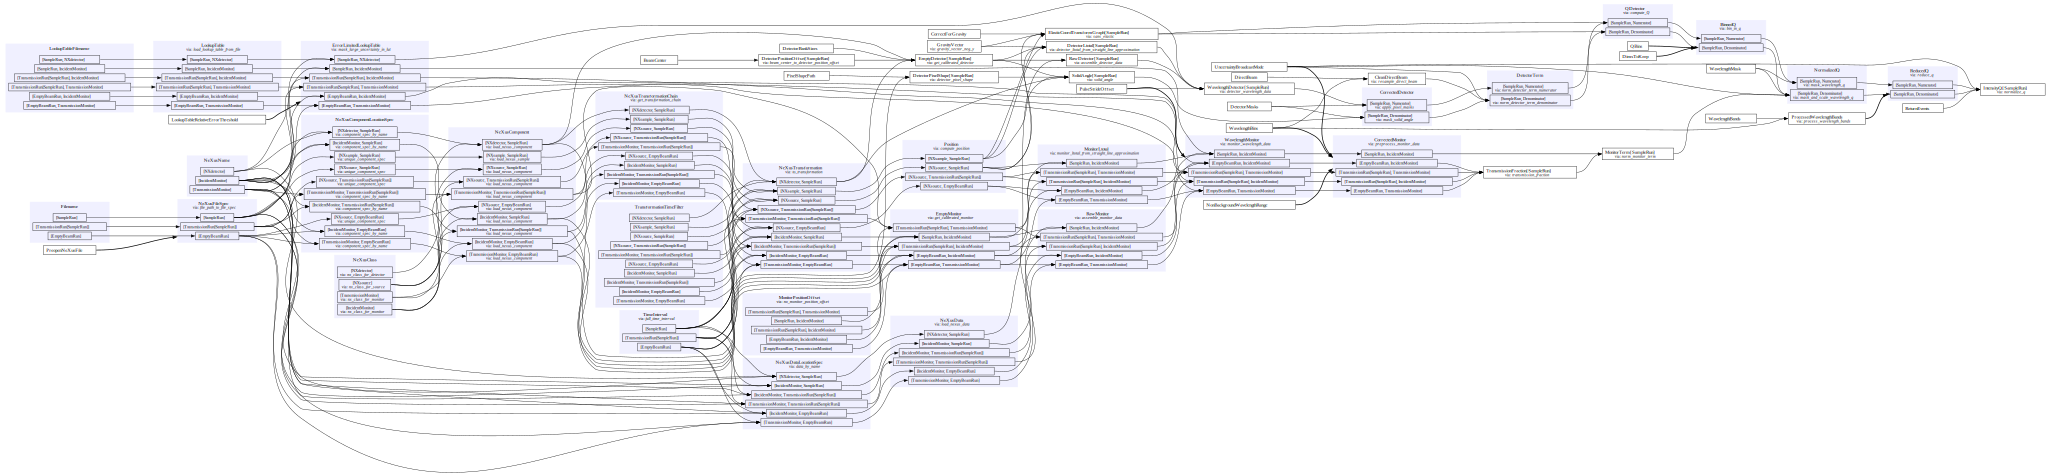

In [2]:
wf = loki.LokiWorkflow()

# Set detector bank name: in this case there is only one bank
wf[NeXusDetectorName] = "loki_detector_0"

# Wavelength and Q binning parameters
wf[WavelengthBins] = sc.linspace("wavelength", 1.0, 13.0, 201, unit="angstrom")
wf[QBins] = sc.linspace(dim="Q", start=0.01, stop=0.3, num=101, unit="1/angstrom")

# Other parameters
wf[CorrectForGravity] = True
wf[UncertaintyBroadcastMode] = UncertaintyBroadcastMode.upper_bound
wf[ReturnEvents] = False
wf[BeamCenter] = sc.vector([0.0, 0.0, 0.0], unit="m")
wf[DirectBeam] = None
wf[DetectorMasks] = {}
wf[LookupTableFilename] = loki.data.loki_lookup_table_no_choppers()

# Use a small dummy file for testing.
# TODO: We currently use the same file for all runs; this should be updated
# once we have files from an actual run.
wf[Filename[SampleRun]] = loki.data.loki_coda_file()
wf[Filename[EmptyBeamRun]] = loki.data.loki_coda_file()
wf[Filename[TransmissionRun[SampleRun]]] = loki.data.loki_coda_file()

# Visualize the workflow
wf.visualize(IntensityQ[SampleRun], graph_attr={'rankdir': 'LR'})

### Compute $I(Q)$

We compute the `IntensityQ` for the sample run.

**Note:** since we are currently using the same file for sample, empty-beam, and transmission runs,
the final results are meaningless (NaNs in all Q bins). However, this should not prevent the workflow
from running.

In [3]:
wf.compute(IntensityQ[SampleRun])

<scipp.DataArray>
Dimensions: Sizes[Q:100, ]
Coordinates:
* Q                         float64           [1/Å]  (Q [bin-edge])  [0.01, 0.0129, ..., 0.2971, 0.3]
* wavelength                float64             [Å]  (wavelength [bin-edge])  [1, 13]
Data:
                            float32  [dimensionless]  (Q)  [-nan, -nan, ..., -nan, -nan]  [-nan, -nan, ..., -nan, -nan]

## Map over detector banks

Loki has 9 detectors banks, and in principle we would want to run the same workflow on all banks
(treating all pixels in the same way).

To compute a reduced result for all banks, we map the workflow over all bank names:

In [4]:
import pandas as pd

bank_ids = list(range(9))
bank_names = [f'loki_detector_{i}' for i in bank_ids]
param_table = pd.DataFrame({NeXusDetectorName: bank_names}, index=bank_ids).rename_axis(
    index='bank_id'
)
param_table

,ess.reduce.nexus.types.NeXusName[scippnexus.nxdetector.NXdetector]
bank_id,
0,loki_detector_0
1,loki_detector_1
2,loki_detector_2
3,loki_detector_3
4,loki_detector_4
5,loki_detector_5
6,loki_detector_6
7,loki_detector_7
8,loki_detector_8


In [5]:
mapped = wf.map(param_table)

results = sciline.compute_mapped(mapped, IntensityQ[SampleRun])

# Convert to a DataGroup for better notebook visualization
sc.DataGroup({str(k): v for k, v in results.items()})

DataGroup(sizes={'Q': 100}, keys=[
    0: DataArray({'Q': 100}),
    1: DataArray({'Q': 100}),
    2: DataArray({'Q': 100}),
    3: DataArray({'Q': 100}),
    4: DataArray({'Q': 100}),
    5: DataArray({'Q': 100}),
    6: DataArray({'Q': 100}),
    7: DataArray({'Q': 100}),
    8: DataArray({'Q': 100}),
])